In [2]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [3]:
data_dir = Path("ldos_combos")
data_dir.is_dir()

True

Text(0.5, 0.98, 'Comparing results around $E=0$ eV')

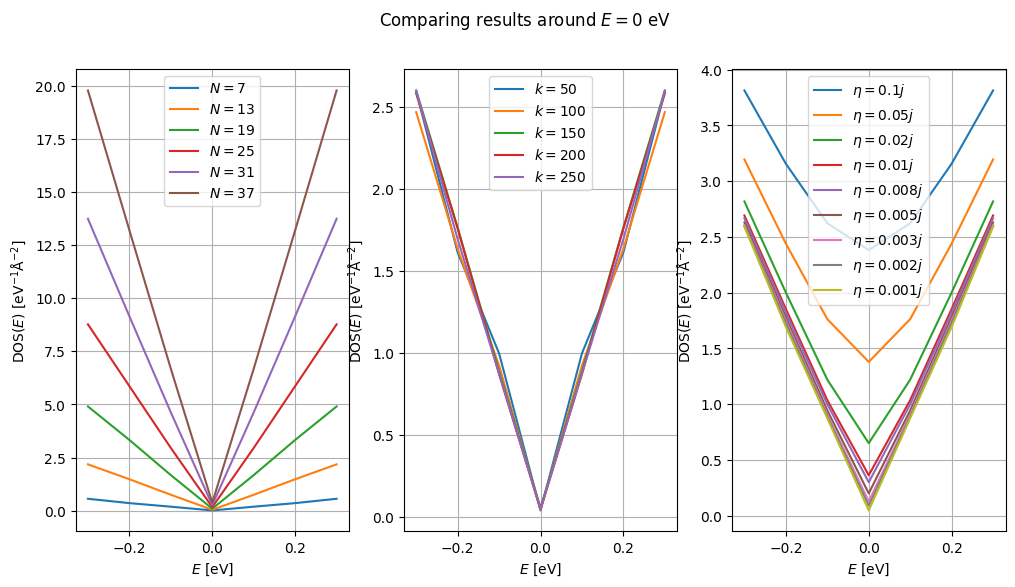

In [4]:
dataN = np.load(data_dir / "ldos-conv-NN.npz")
dataK = np.load(data_dir / "ldos-conv-k.npz")
dataEta = np.load(data_dir / "ldos-conv-eta.npz")
dE = 0.1
Emax = 3.0 # eV
Emin = - Emax
energies = np.array([i*dE for i in range(-3, 4)]); #print(energies)

fig, ax = plt.subplots(1,3, figsize=(12,6))

for key, ldos_dev in dataN.items():
    dos_dev = ldos_dev.sum(axis=0)
    ax[0].plot(energies, dos_dev, label=f"$N = {key}$")
for key, ldos_dev in dataK.items():
    dos_dev = ldos_dev.sum(axis=0)
    ax[1].plot(energies, dos_dev, label=f"$k = {key}$")
for key, ldos_dev in dataEta.items():
    dos_dev = ldos_dev.sum(axis=0)
    ax[2].plot(energies, dos_dev, label=f"$\\eta = {key}$")

for a in ax:
    a.set_ylabel(r"$\mathrm{DOS}(E)\ \left[\mathrm{eV^{-1}\AA^{-2}}\right]$")
    a.set_xlabel(r"$E\ \left[\mathrm{eV}\right]$")
    a.legend()
    a.grid()

fig.suptitle("Comparing results around $E=0$ eV")


site 0  and 03 for Na = 7
site 0  and 06 for Na = 13
site 0  and 09 for Na = 19
site 0  and 12 for Na = 25
site 0  and 15 for Na = 31
site 0  and 18 for Na = 37


/tmp/ipykernel_265872/389772243.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels(ax2.get_yticklabels(), color="r")
/tmp/ipykernel_265872/389772243.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels(ax2.get_yticklabels(), color="r")
/home/bastian/projects/QTM-ML/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/bastian/projects/QTM-ML/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/tmp/ipykernel_265872/389772243.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocato

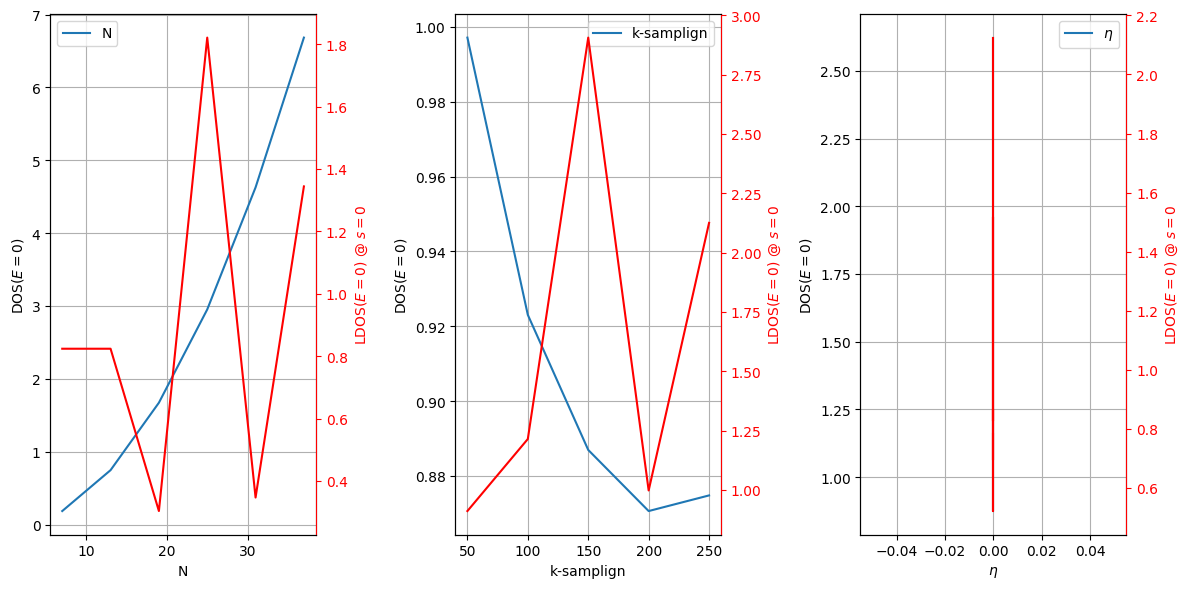

In [28]:
fig, ax = plt.subplots(1,3, figsize=(12,6))


dosE0_N = np.zeros(shape=(len(dataN)))
ldosE0_N_diff = np.zeros_like(dosE0_N)
Ns = np.zeros_like(dosE0_N)
for i, (key, ldos_dev) in enumerate(dataN.items()):
    
    dos_dev = ldos_dev.sum(axis=0)
    nE = len(dos_dev)
    Na = int(key)
    ldosE0_N_diff[i] = np.abs(ldos_dev[0, nE//2 + 1] - ldos_dev[Na//2, nE//2 +1])
    print(f"site 0  and {Na//2:02} for {Na = }")
    dosE0_N[i] = dos_dev[nE // 2 + 1]
    Ns[i] = Na

dosE0_k = np.zeros(shape=(len(dataK)))
ldosE0_k_diff = np.zeros_like(dosE0_k)
ks = np.zeros_like(dosE0_k)
for i, (key, ldos_dev) in enumerate(dataK.items()):
    dos_dev = ldos_dev.sum(axis=0)
    nE = len(dos_dev)
    ldosE0_k_diff[i] = np.abs(ldos_dev[0, nE//2 + 1] - ldos_dev[7, nE//2 +1])
    dosE0_k[i] = dos_dev[nE // 2 + 1]
    ks[i] = float(key)
    
dosE0_eta = np.zeros(shape=(len(dataEta)))
ldosE0_eta_diff = np.zeros_like(dosE0_eta)
etas = np.zeros_like(dosE0_eta, dtype=complex)
for i, (key, ldos_dev) in enumerate(dataEta.items()):
    dos_dev = ldos_dev.sum(axis=0)
    nE = len(dos_dev)
    
    ldosE0_eta_diff[i] = np.abs(ldos_dev[0, nE//2 + 1] - ldos_dev[7, nE//2 +1])
    dosE0_eta[i] = dos_dev[nE // 2 + 1]
    etas[i] = complex(key)


for i, (x, y, y2, label) in enumerate(zip([Ns, ks, etas], [dosE0_N, dosE0_k, dosE0_eta], [ldosE0_N_diff, ldosE0_k_diff, ldosE0_eta_diff], ["N", "k-samplign", "$\\eta$"])):
    ax[i].plot(x, y, label=label)
    ax[i].set_xlabel(f"{label}")
    ax[i].set_ylabel(r"$\mathrm{DOS}(E=0)$")
    
    ax2 = plt.twinx(ax[i])
    ax2.plot(x, y2, 'r-')
    ax2.set_ylabel(r"$\mathrm{LDOS}(E=0)$" + " @ $s=0$", color="r")
    ax2.spines["right"].set_color("r")
    ax2.tick_params(axis="y", color="r")
    ax2.set_yticklabels(ax2.get_yticklabels(), color="r")
    
for a in ax:
    a.legend()
    a.grid()

fig.tight_layout()
# fig.suptitle("Comparing results around $E=0$ eV")
